In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

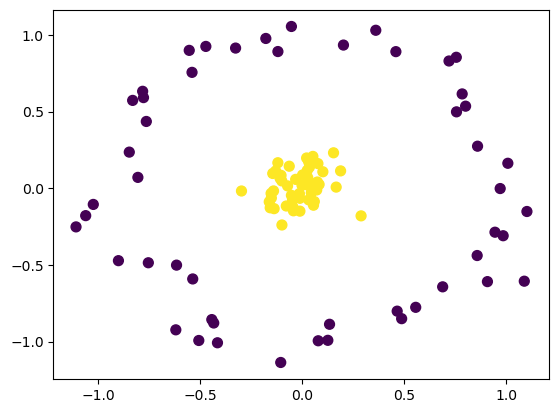

In [4]:
from sklearn.datasets import make_circles

X, y = make_circles(100, factor=0.1, noise=0.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size = 0.20)

In [6]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.65

In [26]:
def plot_decision_boundary(X, y, clf):

    X_set, y_set = X, y

    X1, X2 = np.meshgrid(
        np.arange(
            start=np.min(X_set[:, 0]) - 1,
            stop=np.max(X_set[:, 0]) + 1,
            step=0.01
        ),
        np.arange(
            start=np.min(X_set[:, 1]) - 1,
            stop=np.max(X_set[:, 1]) + 1,
            step=0.01
        )
    )

    plt.contourf(
        X1,
        X2,
        clf.predict(
            np.array([X1.ravel(), X2.ravel()]).T
        ).reshape(X1.shape),
        alpha=0.75,
        cmap=zero_one_colourmap
    )

    plt.xlim(np.min(X1), np.max(X1))
    plt.ylim(np.min(X2), np.max(X2))

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            color=zero_one_colourmap(i),
            label=j
        )

    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()

    return plt.show()

In [27]:
print(X_test.shape)

(20, 2)


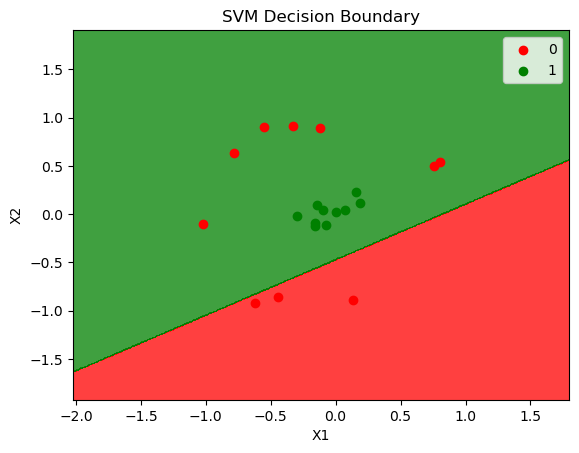

In [28]:
plot_decision_boundary(X_test, y_test, classifier)

In [29]:
def plot_3d_plot(X,y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:,0],X[:,1],r,c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

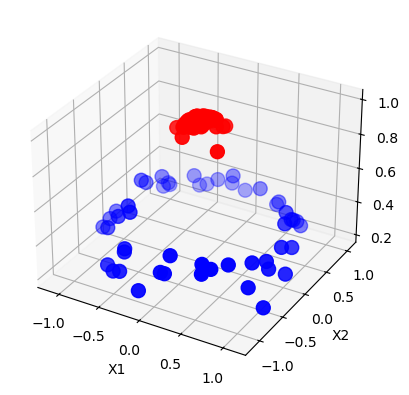

In [30]:
plot_3d_plot(X,y)

In [31]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [32]:
accuracy_score(y_test, y_pred)

1.0

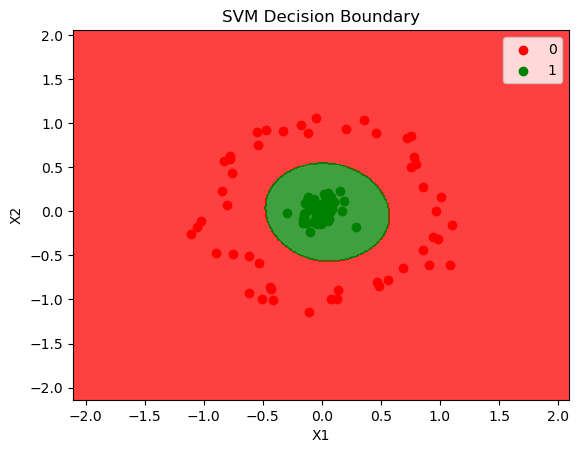

In [33]:
plot_decision_boundary(X,y, rbf_classifier)

In [38]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [40]:
accuracy_score(y_test, y_pred)

1.0